# Getting Started with qneural

**Welcome!** This notebook provides a beginner-friendly introduction to **qneural**, a framework for quantum control optimization with machine learning.

## What You'll Learn

1. How neural networks predict optimal control pulses
2. How to load and use pre-trained quantum gate models
3. How to evaluate gate fidelity (>99% accuracy!)
4. How to use transfer learning for new angle ranges
5. How to visualize control pulses and gate times

## Prerequisites

**No quantum computing background required!** We'll explain concepts as we go.

**What you should know**:
- Basic Python and PyTorch
- Machine learning concepts (neural networks, training)
- High school physics and computer science

## In This Notebook

**qneural** is a modular framework that can support different hardware platforms and methods. Here, we'll use it for generating **2-qubit controlled-phase gates on neutral atoms** - one of its core capabilities with publication-quality results.

**The problem**: Given a desired gate (e.g., controlled-phase with angle φ), find the laser pulses, or controls, to implement it as fast as possible.

**The solution**: Neural networks that predict optimal pulses (near-)instantly!

If you're not familiar with quantum gates or neutral atoms, the background section below explains everything.

## Next Steps After This Notebook

- **For 3-qubit gates** (or if you desire a more technical intro): [ccphase_transfer_learning.ipynb](ccphase_transfer_learning.ipynb)
- **For training from scratch**: [cz_gate_optimization.ipynb](cz_gate_optimization.ipynb)
- **Technical details**: Our paper (Phys. Rev. Applied 23, 054074)

Let's get started!:)

## Setup: Import Libraries

First, let's import the tools we need.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add qneural to path
sys.path.insert(0, str(Path.cwd().parent))

from qneural.utils import load_saved_model
from qneural.neural import TimeOptimalController, TimeOptimalTrainer
from qneural.analysis import plot_gate_time_vs_angle, plot_detuning_pulses

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Background - quantum control on neutral atoms

(You can skip this if you are familiar with quantum computing and neutral atoms)

### The problem: fast, accurate quantum gates

Quantum computers need quantum gates (like classical computers need logic gates). On neutral atom quantum computers, or NAQCs, gates are performed using laser pulses that control trapped atoms.

**The challenge**: Find laser pulses that:
- Implement the desired gate accurately (high fidelity)
- Work as fast as possible (time-optimal)
- Minimize errors from decoherence

### What are neutral atoms?

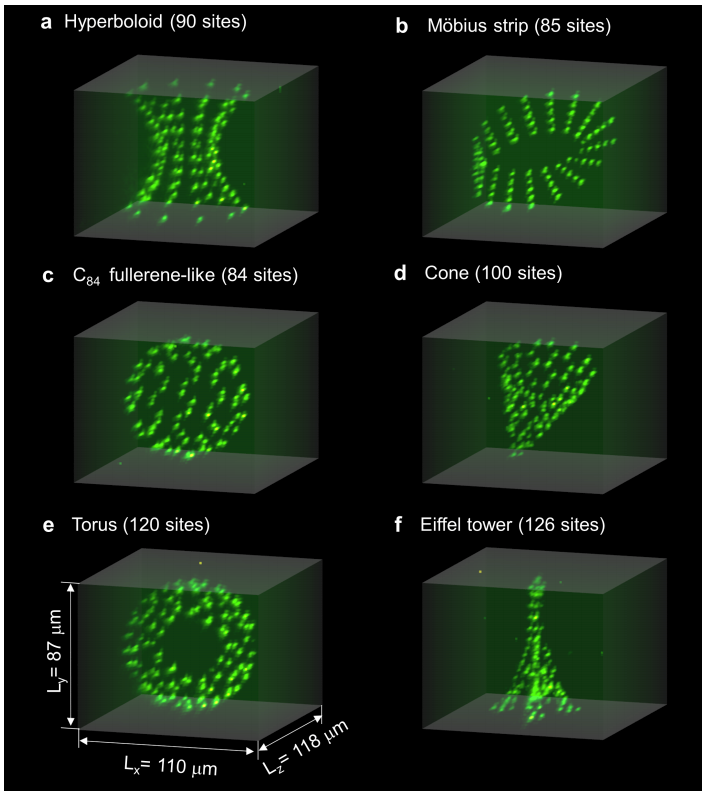

In [13]:
from IPython.display import Image, display
display(Image(filename='atoms.png', width=400))

*Fig. 1: Individual atoms trapped in various 3D patterns, courtesy of Pasqal.*

NAQCs use individual atoms (like **rubidium** or **strontium**) as qubits:

* **Atoms trapped in place** by laser tweezers
* **Each atom is one qubit** (stores quantum information)
* **Lasers control** the atoms' quantum states

**Why neutral atoms?** Scalable, long coherence times, flexible geometry.  
**Companies:** Pasqal (that enabled this library!), Atom Computing, QuEra.

---

### How do we control them?
We use lasers with two key parameters:
1.  **Rabi frequency ($\Omega$):** Laser intensity driving quantum transitions.
2.  **Detuning ($\Delta$):** Laser frequency offset from atomic resonance.

For 2-qubit gates, we excite atoms to **Rydberg states** (highly excited states that interact strongly with neighbors). This **Rydberg blockade** creates entanglement.

---

### The Optimization Challenge
**Traditional approach (GRAPE, Krotov):**
* Solve a complex optimization for each gate.
* Doesn't generalize to new angles—rather, has to be re-run each time.

**qneural's approach (neural networks):**
* Train once on many gates.
* Network learns pattern: $\text{angle} \rightarrow \text{optimal pulses}$.
* After weights learned, we can generate new pulses instantly (milliseconds!).

---

### What is a controlled-phase gate ($CZ_\phi$)?
A 2-qubit gate that applies phase $e^{i\phi}$ only when both qubits are $|1\rangle$.

**Matrix form:**
$$CZ_\phi = \text{diag}(1, 1, 1, e^{i\phi})$$

**Why it matters:** Various algorithms cannot run on current quantum hardware. By generating $CZ_\phi$ gates, we can better fit these algorithms onto hardware (as they allow us to make the circuits compact). *See PRX Quantum 1, 020304 for more info.*

---

### What we'll do:
1.  **Load a pre-trained model** (angles $0.5\pi$ to $\pi$).
2.  **Generate optimal pulses** for any angle.
3.  **Evaluate fidelity** (how accurate is it?).
4.  **Use transfer learning** to extend to new angles.

**Let's see it in action! :)**

## Load a pre-trained model

We've already trained a model on angles from 0.5π to π. Let's load it and see what it can do!

Why start with a pre-trained model? There are two common workflows:

1. Train from scratch ([cz_gate_optimization.ipynb](cz_gate_optimization.ipynb)): Start with random weights, optimize for a specific gate or angle range. This is the foundation - it takes hours to days depending on the problem.

2. Use pre-trained models (this notebook): Start with a network already optimized over a large angle range. This is faster for getting results and serves as an excellent starting point for transfer learning to new regions.

The full workflow: You can train from scratch first (workflow 1), then use that trained model as an initial guess for more complex problems or new angle ranges (workflow 2 + transfer learning below). Here, we skip straight to using a publication-quality pre-trained model that already works well across 0.5π to π.

In [2]:
# Load pre-trained model
model_path = '../qneural/data/publication_models/pt5pi_to_pi.pt'

print("Loading pre-trained model...")
print("=" * 60)

controller, checkpoint = load_saved_model(
    model_path,
    print_metadata=True,      # Show model info
    evaluate_fidelity=True,   # Test performance
    n_eval_angles=20          # Test on 20 angles
)

print("\n✓ Model loaded successfully!")

Loading pre-trained model...
Model Metadata:
  source: archival_publication
  original_file: pt5pi_to_pi
  note: Publication-quality results for CZ gate (0.5π = π ...
  missing_data: ['training_history', 'epoch_count', 'optimizer_states']
  angle_range: [0.5000π, 1.0000π]
  angle_range_tensor: [0.5000π, 0.5000π]
  angle_range_source: network_attribute

Controller Configuration:
  Qubits: 2
  Time network: 1 layers x 45 units (sigmoid)
  Control network: 9 layers x 300 units
  Time bounds: [0.1611, 0.3382] s
  Rabi max: 25.13 MHz
  Time steps: 201
  Total parameters: 723,737

Evaluating fidelity on 20 angles...

Fidelity Statistics:
  Mean: 99.8840%
  Min: 99.7513%
  Max: 99.9987%
  Std: 0.0899%
  All > 99%: True

✓ Model loaded successfully!


### Understanding the output

Let's break down what we just saw:

**Model Metadata**:
- `angle_range`: [0.5π, π] - the angles this model was trained on
- `nqubits`: 2 - this is a 2-qubit gate
- `source`: archival_publication - from our published research

**Controller Configuration**:
- `Time network`: Predicts how long the gate takes (1 layer × 60 neurons)
- `Control network`: Generates the detuning pulse (9 layers × 300 neurons)
- `Time bounds`: Min/max possible gate times
- `Rabi max`: 25.13 MHz - the fixed laser intensity
- `Time steps`: 201 - pulse is discretized into 201 time steps

**Fidelity Statistics**:
- `Mean: >99%` - the gate is very accurate!
- `All > 99%: True` - all 20 test angles passed

**What is fidelity?**
- Measures how close the achieved gate is to the target
- `100%` = perfect gate
- `>99%` is desirable for quantum computing
- `<95%` typically means something is wrong

## Using the model to predict control pulses

Now let's use the model to generate control pulses for a specific angle, check its fidelity, and visualize the pulse!

**Example**: Let's make a CZ_φ gate with φ = 0.75π

In [3]:
# Choose an angle (must be in trained range [0.5π, π])
angle = 0.75 * np.pi

print(f"Generating control pulse for φ = {angle/np.pi:.2f}π...")
print("=" * 60)

# Convert to tensor (neural networks need tensors)
angle_tensor = torch.tensor([[angle]])

# Forward pass through the neural network
with torch.no_grad():  # Don't track gradients (we're not training)
    gate_time, detuning_values = controller(angle_tensor)

print(f"\nNeural Network Predictions:")
print(f"  Optimal gate time: {gate_time.item():.4f} seconds")
print(f"  Optimal gate time: {gate_time.item() * controller.rabi_max:.2f} × (1/Ω_max)")
print(f"  Detuning pulse shape: {detuning_values.shape}")
print(f"    → [{detuning_values.shape[1]} time steps x {detuning_values.shape[2]} control]")

print(f"\n✓ Pulse generated in milliseconds!")
print(f"  (Traditional methods would take minutes to hours)")

# Evaluate fidelity for this specific angle
print(f"\nEvaluating fidelity for φ = {angle/np.pi:.2f}π...")
print("(Simulating quantum evolution - takes ~2-3 seconds)")

trainer = TimeOptimalTrainer(controller=controller, nqubits=2, time_weight=0.005)
# Pass as 1D tensor [angle] instead of 0D scalar
results = trainer.evaluate(torch.tensor([angle]))
fidelity = (1 - results['infidelities'][0]) * 100

print(f"\n✓ Fidelity: {fidelity:.4f}%")
print(f"  {'Excellent!' if fidelity > 99.9 else 'Very good!' if fidelity > 99 else 'Good'}")

Generating control pulse for φ = 0.75π...

Neural Network Predictions:
  Optimal gate time: 0.3040 seconds
  Optimal gate time: 7.64 × (1/Ω_max)
  Detuning pulse shape: torch.Size([1, 201, 1])
    → [201 time steps x 1 control]

✓ Pulse generated in milliseconds!
  (Traditional methods would take minutes to hours)

Evaluating fidelity for φ = 0.75π...
(Simulating quantum evolution - takes ~2-3 seconds)

✓ Fidelity: 99.9999%
  Excellent!


### Visualize this pulse

Let's plot what this specific pulse looks like:

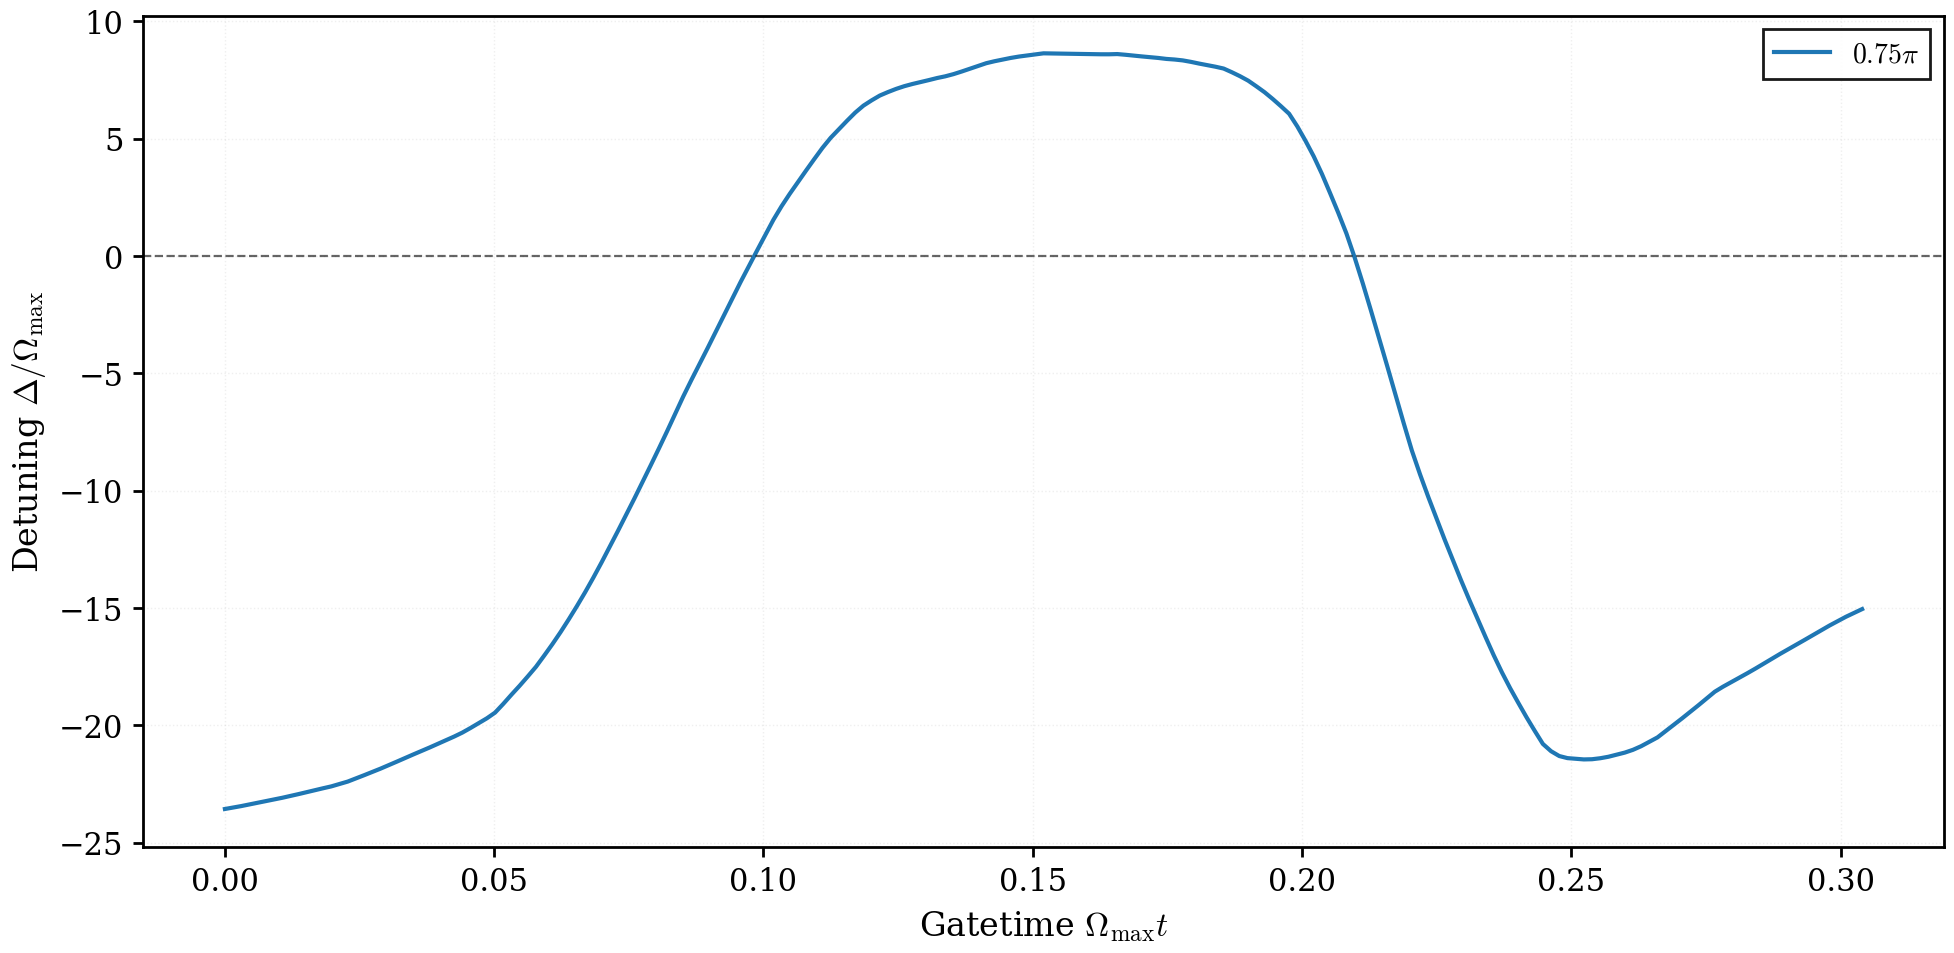


📊 What you're seeing:
  - X-axis: Time during gate operation
  - Y-axis: Detuning (laser frequency offset)
  - This pulse implements CZ_0.75π with 100.00% fidelity!


In [4]:
# Visualize this specific pulse
fig = plot_detuning_pulses(
    controller,
    torch.tensor([angle]),
    rabi_max=controller.rabi_max,
    single_plot=True,
    figsize=(10, 5),
    n_time_steps=controller.n_time_steps
)
plt.show()

print("\n📊 What you're seeing:")
print(f"  - X-axis: Time during gate operation")
print(f"  - Y-axis: Detuning (laser frequency offset)")
print(f"  - This pulse implements CZ_{angle/np.pi:.2f}π with {fidelity:.2f}% fidelity!")

## Visualize control pulses for multiple angles

Now let's see how the pulses change across different angles.

Generating pulses for 6 different angles...


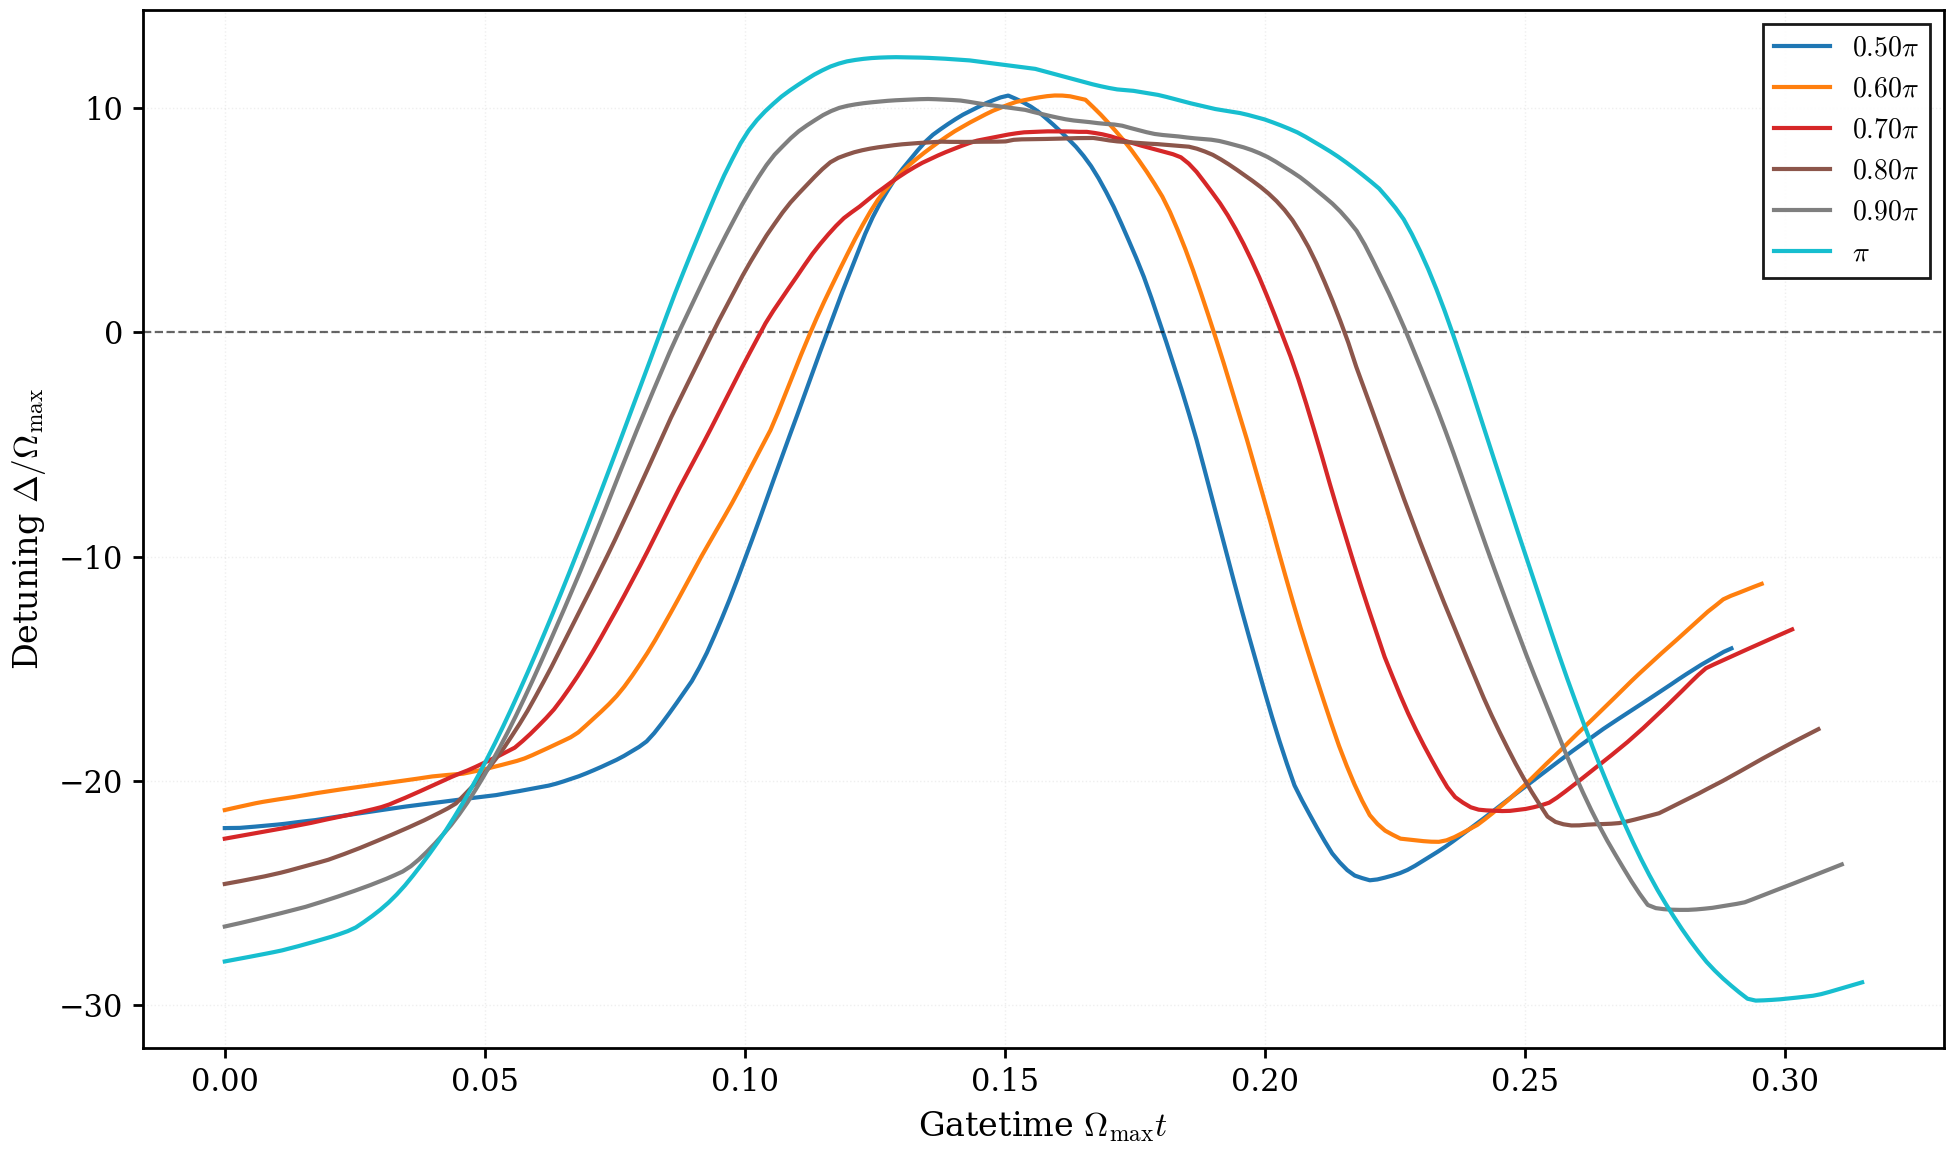

✓ Visualization complete!


In [5]:
# Generate pulses for multiple angles
sample_angles = torch.linspace(0.5 * np.pi, np.pi, 6)

print("Generating pulses for 6 different angles...")
fig = plot_detuning_pulses(
    controller,
    sample_angles,
    rabi_max=controller.rabi_max,
    single_plot=True,
    figsize=(10, 6),
    n_time_steps=controller.n_time_steps
)
plt.show()

print("✓ Visualization complete!")

### Understanding the plot

**What you're seeing**:
- Each colored line is a different control pulse
- The neural network learned that different angles need different pulse shapes

**Physical intuition**:
- **Positive detuning** (Δ > 0): Laser blue-detuned from atomic transition
- **Negative detuning** (Δ < 0): Laser red-detuned
- The specific shape encodes the quantum dynamics needed for each angle

In [6]:
# Evaluate fidelity on multiple test angles
print("Evaluating fidelity on 15 test angles...")
print("(This takes ~30 seconds)")
print("=" * 60)

test_angles = torch.linspace(0.5 * np.pi, np.pi, 15)
results = trainer.evaluate(test_angles)

# Extract fidelities (convert from infidelity)
fidelities = [(1 - inf) * 100 for inf in results['infidelities']]

print(f"\nFidelity Statistics:")
print(f"  Mean: {np.mean(fidelities):.4f}%")
print(f"  Min: {np.min(fidelities):.4f}%")
print(f"  Max: {np.max(fidelities):.4f}%")
print(f"  Std: {np.std(fidelities):.4f}%")
print(f"  All > 99%: {all(f > 99 for f in fidelities)}")

print("\n✓ Fidelity evaluation complete!")

Evaluating fidelity on 15 test angles...
(This takes ~30 seconds)

Fidelity Statistics:
  Mean: 99.8853%
  Min: 99.7508%
  Max: 99.9995%
  Std: 0.0897%
  All > 99%: True

✓ Fidelity evaluation complete!


### Interpreting fidelity

**What's considered good?**
- `>99.9%`: Optimal! Publication-quality results
- `99-99.9%`: Decent for near-term computers
- `95-99%`: Okay, but could be improved
- `<95%`: Poor, likely a problem with the model or parameters

**Why not 100%?**
- Neural networks find approximate solutions
- Numerical integration has small errors
- But >99.9% is good enough for real quantum computers!

## Transfer learning - training on new angles

**This is the main event!** Here we will explore how we can train neural networks to obtain the high-fidelity pulses we have already presented above.

### The two connected approaches

Both approaches are essential and work together:

1. **Training from scratch** ([cz_gate_optimization.ipynb](cz_gate_optimization.ipynb)): Start with random weights, optimize a network for a specific angle (like CZ_π). This is how you get your first working model. 

2. **Transfer learning** (this section): Once you have a model trained on one angle or range, use it as an initial guess to extend to new regions. Much faster than starting from scratch!

### Why this is powerful

The [cz_gate_optimization.ipynb](cz_gate_optimization.ipynb) notebook showed training for a single fixed angle. That's nice for understanding the basics. But here's what's even better: we loaded a model that already works well across a whole range (0.5π to π). Now we'll use it as our initial guess to learn a new range (0.3π to 0.5π).

**The workflow**:
- Start: Train one angle, or a small range of angles, from scratch (slow but necessary)
- Build: Extend to a range using that as initialization  
- Scale: Use that range model to learn adjacent ranges (what we're doing here!)
- Result: Quickly build a library of models covering all angles you need

### Let's do it!

We have a model trained on [0.5π, π]. Let's fine-tune it to work on [0.3π, 0.5π]. The network already knows good pulse patterns - it just needs to adapt them to smaller angles.

### Training configuration

For this demo, we'll train for a moderate number of epochs. In practice, you might train longer for better results.

**Training parameters**:
- `epochs`: Number of training iterations
- `batch_size`: Number of angles per iteration
- `angle_range`: Range to sample training angles from
- `resample_every`: Resample new angles every N epochs (prevents overfitting)

**Note**: Training can take 30 minutes to a few hours depending on your hardware. For this demo, we'll use modest settings.

In [7]:
# Transfer learning configuration
NEW_ANGLE_RANGE = (0.3 * np.pi, 0.5 * np.pi)  # New range to learn
EPOCHS = 200  # Moderate for demo (use 500-1000 for production)
BATCH_SIZE = 50  # Number of angles per batch

print("Transfer Learning Configuration:")
print("=" * 60)
print(f"  Original range: [0.5π, π]")
print(f"  New range: [0.3π, 0.5π]")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"\n⚠️  Note: Training takes time! For production, use more epochs.")

# Evaluate model on new range BEFORE transfer learning
print(f"\nEvaluating pre-trained model on NEW range [0.3π, 0.5π] (before training)...")
eval_angles_new = torch.linspace(NEW_ANGLE_RANGE[0], NEW_ANGLE_RANGE[1], 10)
results_before = trainer.evaluate(eval_angles_new)
fidelities_before = [(1 - inf) * 100 for inf in results_before['infidelities']]

print(f"  Mean fidelity BEFORE: {np.mean(fidelities_before):.2f}%")
print(f"  Min fidelity BEFORE: {np.min(fidelities_before):.2f}%")
print(f"  (Likely not optimal - that's what transfer learning will fix!)")

Transfer Learning Configuration:
  Original range: [0.5π, π]
  New range: [0.3π, 0.5π]
  Epochs: 200
  Batch size: 50

⚠️  Note: Training takes time! For production, use more epochs.

Evaluating pre-trained model on NEW range [0.3π, 0.5π] (before training)...
  Mean fidelity BEFORE: 90.30%
  Min fidelity BEFORE: 73.24%
  (Likely not optimal - that's what transfer learning will fix!)


In [8]:
# Generate training angles
training_angles = torch.rand(BATCH_SIZE, 1) * (NEW_ANGLE_RANGE[1] - NEW_ANGLE_RANGE[0]) + NEW_ANGLE_RANGE[0]

print("Starting transfer learning training...")
print("=" * 60)
print("⏱️  This will take a few minutes...\n")

history = trainer.train(
     angles=training_angles,
     epochs=EPOCHS,
     angle_range=NEW_ANGLE_RANGE,
     resample_every=50,
     print_every=25
 )

print("✓ Training complete!")

Starting transfer learning training...
⏱️  This will take a few minutes...

Epoch 0: Loss = 0.075436, Infidelity = 0.074009, Mean Time = 7.1727
Epoch 25: Loss = 0.009483, Infidelity = 0.008055, Mean Time = 7.1729
Epoch 50: Loss = 0.003078, Infidelity = 0.001655, Mean Time = 7.1506
Epoch 75: Loss = 0.002574, Infidelity = 0.001152, Mean Time = 7.1506
Epoch 100: Loss = 0.002343, Infidelity = 0.000917, Mean Time = 7.1681
Epoch 125: Loss = 0.002294, Infidelity = 0.000868, Mean Time = 7.1681
Epoch 150: Loss = 0.002393, Infidelity = 0.000969, Mean Time = 7.1573
Epoch 175: Loss = 0.002345, Infidelity = 0.000921, Mean Time = 7.1572
✓ Training complete!


In [9]:
# Re-evaluate on new range after training
results_after = trainer.evaluate(eval_angles_new)
fidelities_after = [(1 - inf) * 100 for inf in results_after['infidelities']]

print("Results AFTER fine-tuning:")
print("=" * 60)
print(f"  Mean fidelity: {np.mean(fidelities_after):.4f}%")
print(f"  Min fidelity: {np.min(fidelities_after):.4f}%")
print(f"  Max fidelity: {np.max(fidelities_after):.4f}%")
print(f"\n  Improvement: {np.mean(fidelities_after) - np.mean(fidelities_before):.2f}%")
print(f"\n✓ Transfer learning successful!")

print("After training, you would evaluate again to see improvement!")
print("\nExpected results:")
print("  - Fidelities > 99% on new range [0.3π, 0.5π]")
print("  - Significant improvement from before training")
print("  - Faster convergence than training from scratch")

Results AFTER fine-tuning:
  Mean fidelity: 99.9153%
  Min fidelity: 99.7571%
  Max fidelity: 99.9976%

  Improvement: 9.62%

✓ Transfer learning successful!
After training, you would evaluate again to see improvement!

Expected results:
  - Fidelities > 99% on new range [0.3π, 0.5π]
  - Significant improvement from before training
  - Faster convergence than training from scratch


### Save your new model

In [10]:
# Save the fine-tuned model
save_path = 'my_cphase_model_0.3pi_to_pi.pt'

metadata = {
    'source': 'transfer_learning',
    'parent_model': 'pt5pi_to_pi.pt',
    'original_range': (0.5 * np.pi, np.pi),
    'new_range': NEW_ANGLE_RANGE,
    'combined_range': (NEW_ANGLE_RANGE[0], np.pi),  # Now covers [0.3π, π]
    'epochs_trained': EPOCHS,
    'note': 'Fine-tuned from 0.5-1.0π model to extend coverage to 0.3-0.5π range'
}

trainer.save_checkpoint(save_path, metadata=metadata)

print("✓ Model saved successfully!")
print(f"  Saved to: {save_path}")
print(f"\n  This model now covers: [0.3π, π]")
print(f"  - Original range [0.5π, π]: Already optimized")
print(f"  - New range [0.3π, 0.5π]: Just fine-tuned!")
print(f"\nTo load this model later:")
print(f"  controller, ckpt = load_saved_model('{save_path}')")

✓ Model saved successfully!
  Saved to: my_cphase_model_0.3pi_to_pi.pt

  This model now covers: [0.3π, π]
  - Original range [0.5π, π]: Already optimized
  - New range [0.3π, 0.5π]: Just fine-tuned!

To load this model later:
  controller, ckpt = load_saved_model('my_cphase_model_0.3pi_to_pi.pt')


## Summary and Next Steps

You've learned:

✅ How to load pre-trained quantum gate models

✅ How neural networks predict optimal control pulses

✅ How to evaluate gate fidelity (>99% is excellent!)

✅ How to use transfer learning for new angle ranges

✅ How to visualize control pulses and gate times

### Key Takeaways

1. **Neural networks can learn quantum control**: Once trained, they generate pulses instantly
2. **Transfer learning is powerful**: Extend to new angle ranges without starting from scratch
3. **>99% fidelity is achievable**: These are publication-quality results
4. **Time-optimal is important**: Faster gates = better quantum computers

### What's Next?

**Ready for more?**

1. **3-qubit gates**: Check out [ccphase_transfer_learning.ipynb](ccphase_transfer_learning.ipynb) for CCZ_φ gates
   - Same concepts, but with 3 qubits!
   - More complex, but qneural handles it automatically

2. **Train from scratch**: See [cz_gate_optimization.ipynb](cz_gate_optimization.ipynb)
   - Learn how to train for a single angle
   - Understanding the full training pipeline

3. **Technical details**: See [cphase_transfer_learning.ipynb](cphase_transfer_learning.ipynb)
   - More concise, assumes familiarity
   - Good for researchers

4. **Read the paper**: Phys. Rev. Applied 23, 054074
   - Full mathematical details
   - Benchmarks and comparisons

### Questions or Issues?

- **Documentation**: Check the README.md
- **Issues**: Report bugs on GitHub
- **Paper**: See references in README

Happy quantum controlling! 🚀🔬